In [46]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
#loading dataset
df = pd.read_csv("../Data/EstateProductivityPrediction_dataset.CSV")

In [40]:
#Exploratary data analysis (EDA)
df.head(30)

,year,month,month_num,wet_days,rainfall,female_workforce,male_workforce,temperature_T2M,irradiance_SW_DWN,yield
0,2016,April,4,9.0,163.0,NaN,NaN,25.00,6.1423,NaN
1,2016,May,5,28.0,1352.0,NaN,NaN,24.05,4.2475,NaN
2,2016,June,6,24.0,631.0,NaN,NaN,22.86,5.0206,NaN
3,2016,July,7,18.0,448.0,NaN,NaN,22.51,5.0669,NaN
4,2016,August,8,20.0,614.0,NaN,NaN,22.76,5.1598,NaN
5,2016,September,9,11.0,160.0,NaN,NaN,22.71,5.4122,NaN
6,2016,October,10,16.0,444.0,NaN,NaN,23.06,5.3230,NaN
7,2016,November,11,16.0,577.0,NaN,NaN,22.37,4.1700,NaN
8,2016,December,12,3.0,151.0,NaN,NaN,21.75,4.9634,NaN
9,2017,January,1,7.0,99.0,NaN,NaN,21.26,5.1437,NaN


In [51]:
df.shape

(115, 10)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               115 non-null    int64  
 1   month              115 non-null    object 
 2   month_num          115 non-null    int64  
 3   wet_days           109 non-null    float64
 4   rainfall           109 non-null    float64
 5   female_workforce   9 non-null      float64
 6   male_workforce     9 non-null      float64
 7   temperature_T2M    115 non-null    float64
 8   irradiance_SW_DWN  115 non-null    float64
 9   yield              96 non-null     float64
dtypes: float64(7), int64(2), object(1)
memory usage: 9.1+ KB


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,115.0,2020.539130,2.791865,2016.00,2018.00000,2021.0000,2023.00000,2025.0000
month_num,115.0,6.530435,3.398456,1.00,4.00000,7.0000,9.00000,12.0000
wet_days,109.0,16.642202,7.167988,2.00,11.00000,17.0000,23.00000,30.0000
rainfall,109.0,469.568807,336.178534,41.00,202.00000,428.0000,674.00000,1393.0000
female_workforce,9.0,264.777778,78.498054,157.00,194.00000,286.0000,321.00000,367.0000
male_workforce,9.0,349.555556,99.235970,208.00,279.00000,369.0000,425.00000,486.0000
temperature_T2M,115.0,22.834696,0.890510,20.51,22.34500,22.8000,23.37500,25.2700
irradiance_SW_DWN,115.0,-3.692816,93.628713,-999.00,4.68375,4.9622,5.47815,6.3634
yield,96.0,43301.218750,14153.937309,16821.00,33286.25000,41087.0000,51588.25000,88699.0000


In [30]:
df.describe(include="object").T

,count,unique,top,freq
month,115,12,April,10


In [37]:
#null/missing values
df.isnull().sum()

Missing values: 


year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
female_workforce     106
male_workforce       106
temperature_T2M        0
irradiance_SW_DWN      0
yield                 19
dtype: int64

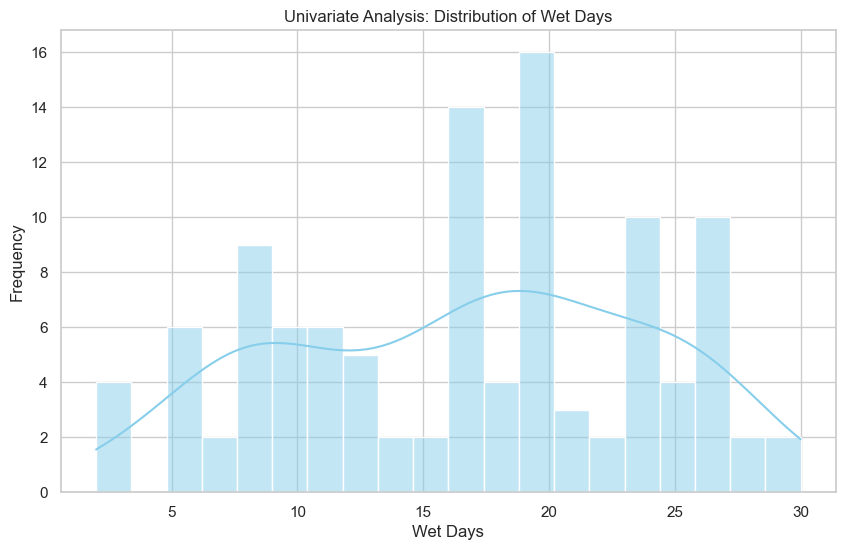

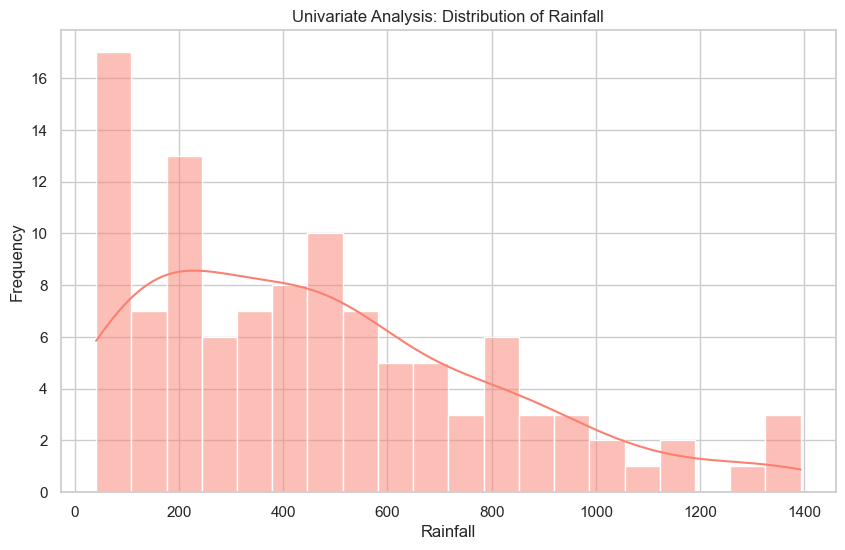

In [57]:
#Handling missing values

#plotting the features to understand better

#Set the visual style
sns.set_theme(style="whitegrid")

#Plot Histogram for 'wet_days'
plt.figure(figsize=(10, 6))
sns.histplot(df['wet_days'].dropna(), kde=True, color='skyblue', bins=20)
plt.title('Univariate Analysis: Distribution of Wet Days')
plt.xlabel('Wet Days')
plt.ylabel('Frequency')
plt.show()

#Plot Histogram for 'rainfall'
plt.figure(figsize=(10, 6))
sns.histplot(df['rainfall'].dropna(), kde=True, color='salmon', bins=20)
plt.title('Univariate Analysis: Distribution of Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.show()

In [59]:
#handling missing values of the rainfall and wet days column
df['rainfall']=(df.groupby('month')['rainfall'].transform(lambda x: x.fillna(x.median())))         #median because rainfall is skewed

df['wet_days']=(df.groupby('month')['wet_days'].transform(lambda x: x.fillna(x.mean())))

# Final check
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               0
rainfall               0
female_workforce     106
male_workforce       106
temperature_T2M        0
irradiance_SW_DWN      0
yield                 19
dtype: int64

In [36]:
#duplicate records
print('Number of Duplicate Records: ',df.duplicated().sum())

Number of Duplicate Records:  0


In [38]:
#checking for structural errors/incorrect naming conventions
df['month'].unique()

array(['April', 'May', 'June', 'July', 'August', 'September', 'October',
       'November', 'December', 'January', 'February', 'March'],
      dtype=object)

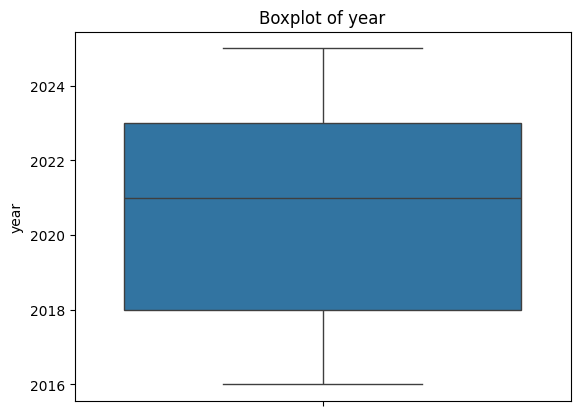

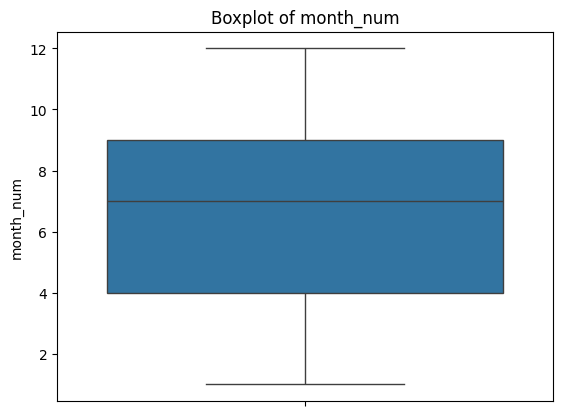

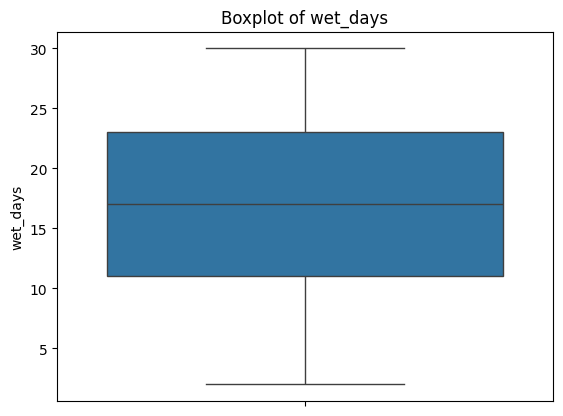

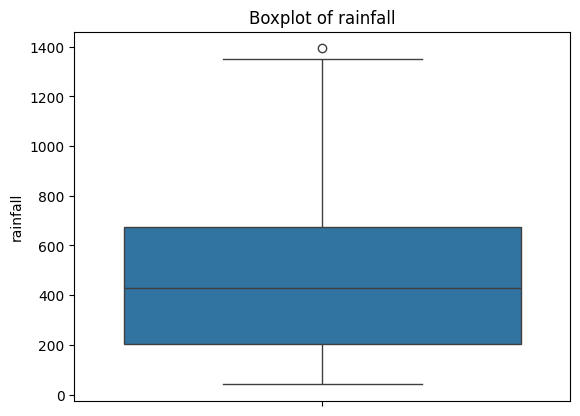

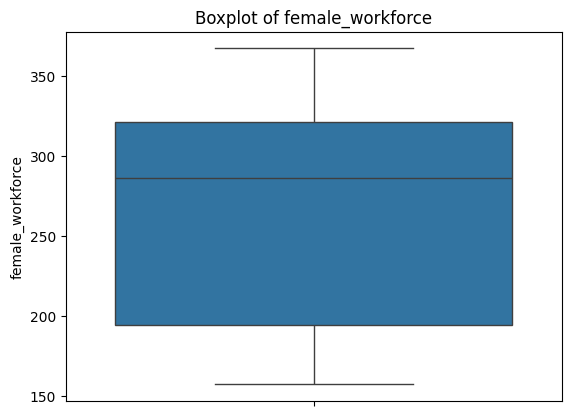

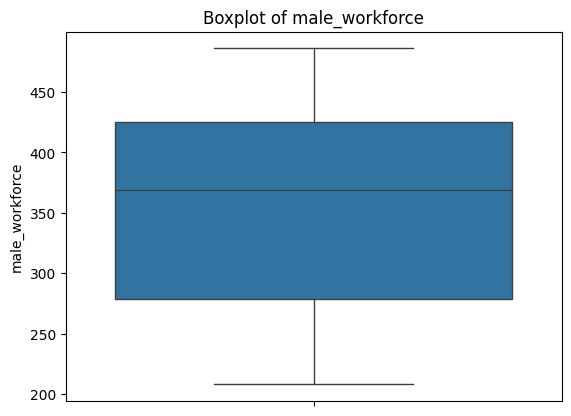

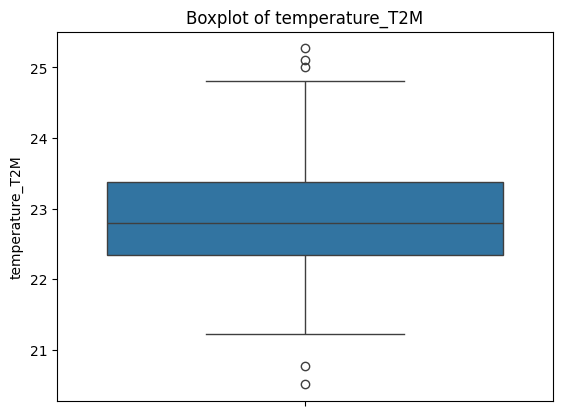

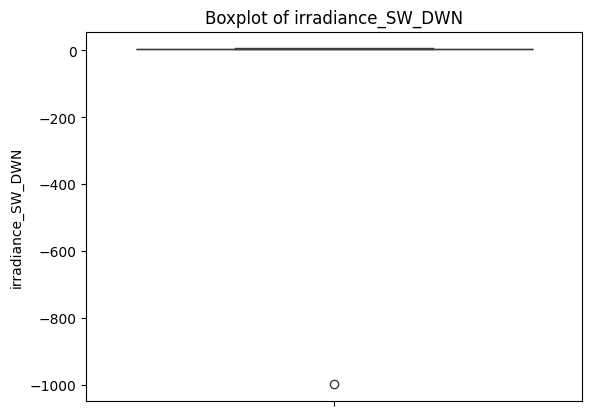

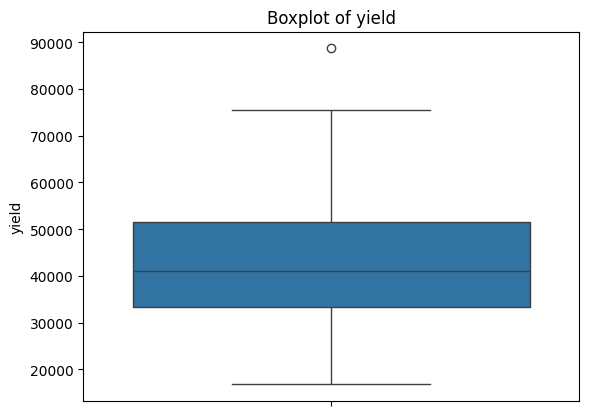

In [47]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.boxplot(data=df,y=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

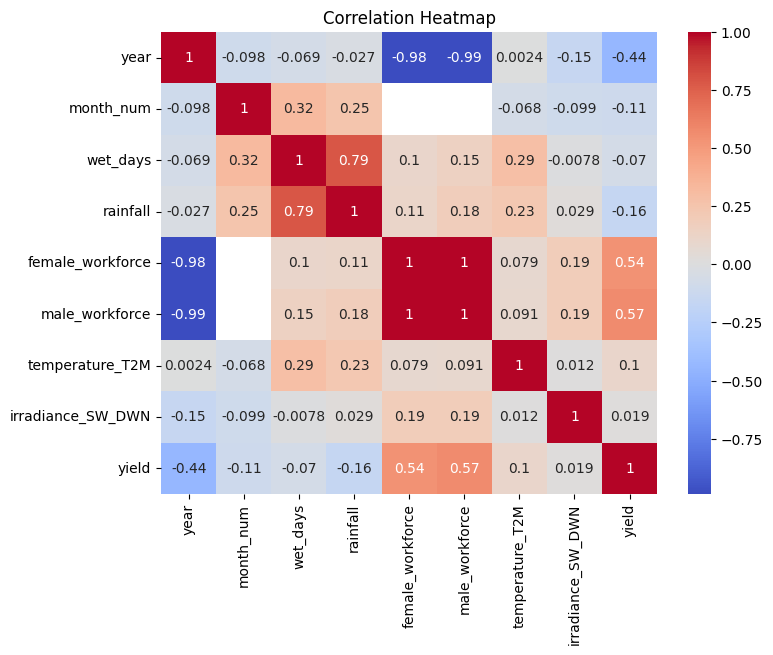

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()